In [5]:
from hierarchical_clustering_invariant import *
from utils import *
import numpy as np
import matplotlib.pyplot as plt
from find_best_K import find_best_K_F, generate_alpha_list_exp
from scipy.cluster.hierarchy import linkage, fcluster

In [20]:
from scipy.cluster.hierarchy import linkage, fcluster, cut_tree
def generate_3cluster_data_varsize(n, p=2, delta=1.0, sigma=1.0, seed = None):
    n_each = n//3
    rng = np.random.default_rng(seed)
    cov = np.eye(p) * (sigma ** 2)
    mu1 = np.zeros(p); mu1[0] = -delta/2
    mu2 = np.zeros(p); mu2[-1] = np.sqrt(3)*delta/2
    mu3 = np.zeros(p); mu3[0] = delta/2
    X1 = multivariate_normal.rvs(mean=mu1, cov=cov, size=n_each, random_state=rng)
    X2 = multivariate_normal.rvs(mean=mu2, cov=cov, size=n_each, random_state=rng)
    X3 = multivariate_normal.rvs(mean=mu3, cov=cov, size=n_each, random_state=rng)
    X = np.vstack([X1, X2, X3])
    labels = np.array([0]*n_each + [1]*n_each + [2]*n_each)
    return X, labels

def generate_Kcluster_equal(n=120, p=2, K=3, delta=3.0, sigma=1.0, seed=None):
    rng = np.random.default_rng(seed)
    cov = np.eye(p) * (sigma ** 2)

    angles = np.linspace(0, 2*np.pi, K, endpoint=False)
    centers = np.stack([delta * np.cos(angles), delta * np.sin(angles)], axis=1)

    n_per = n // K
    remainder = n % K

    X_list = []
    labels = []

    for k in range(K):
        nk = n_per + (1 if k < remainder else 0)
        Xk = multivariate_normal.rvs(mean=centers[k], cov=cov, size=nk, random_state=rng)
        X_list.append(Xk)
        labels.extend([k] * nk)

    X = np.vstack(X_list)
    return X, np.array(labels), centers
def generate_Kcluster_custom(p=2, K=3, delta=3.0, sigma=1.0,
                             cluster_sizes=None, seed=None):
    rng = np.random.default_rng(seed)
    cov = np.eye(p) * (sigma ** 2)

    angles = np.linspace(0, 2*np.pi, K, endpoint=False)
    centers = np.stack([delta * np.cos(angles), delta * np.sin(angles)], axis=1)

    if cluster_sizes is None:
        n = 120
        n_per = n // K
        remainder = n % K
        cluster_sizes = [n_per + (1 if k < remainder else 0) for k in range(K)]

    X_list = []
    labels = []

    for k in range(K):
        nk = cluster_sizes[k]
        Xk = multivariate_normal.rvs(mean=centers[k], cov=cov,
                                     size=nk, random_state=rng)
        X_list.append(Xk)
        labels.extend([k] * nk)

    X = np.vstack(X_list)
    return X, np.array(labels), centers

def wcss_from_labels(X, labels):
    return sum(((X[labels==k] - X[labels==k].mean(axis=0))**2).sum() for k in np.unique(labels))

def compute_wcss_hclust(X, n_clusters):
    n = X.shape[0]
    if n_clusters <= 1:
        labels = np.ones(n, dtype=int)
        return wcss_from_labels(X, labels)
    if n_clusters >= n:
        return 0.0

    Z = linkage(X, method="ward")
    labels = cut_tree(Z, n_clusters=n_clusters).reshape(-1)
    n_found = len(np.unique(labels))

    if n_found != n_clusters:
        print(f"Warning: requested {n_clusters} clusters, got {n_found}")

    return wcss_from_labels(X, labels)

def gap_statistic(X, K_max=30, B=50, eps=1e-12):
    n = X.shape[0]
    K_max = min(K_max, n - 1)

    rng = np.random.RandomState(0)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    log_wcss = np.zeros(K_max)
    gap = np.zeros(K_max)
    sk = np.zeros(K_max)

    for k in range(1, K_max + 1):
        wk = compute_wcss_hclust(X, k)
        log_wcss[k - 1] = np.log(max(wk, eps))

        wk_refs = np.zeros(B)
        for b in range(B):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            wk_refs[b] = compute_wcss_hclust(X_ref, k)

        log_wk_refs = np.log(np.maximum(wk_refs, eps))
        gap[k - 1] = np.mean(log_wk_refs) - log_wcss[k - 1]
        sk[k - 1] = np.std(log_wk_refs, ddof=1) * np.sqrt(1 + 1 / B)

    for k in range(1, K_max):
        if gap[k - 1] >= gap[k] - sk[k]:
            return k

    return K_max

def gap_statistic(X, K_max=30, B=50, eps = 1e-12):
    rng = np.random.RandomState(0)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)
    log_wcss = np.zeros(K_max)
    gap = np.zeros(K_max)
    sk = np.zeros(K_max)
    for k in range(1, K_max + 1):
        wk = compute_wcss_hclust(X, k)
        log_wcss[k - 1] = np.log(wk)
        wk_refs = np.zeros(B)
        for b in range(B):
            X_ref = rng.uniform(mins, maxs, size=X.shape)
            wk_refs[b] = compute_wcss_hclust(X_ref, k)
        log_wk_refs = np.log(np.maximum(wk_refs, eps))
        gap[k-1] = np.mean(log_wk_refs) - log_wcss[k-1]
        sk[k-1] = np.std(log_wk_refs)*np.sqrt(1+1/B)
    for k in range(1, K_max):
        if gap[k-1] >= gap[k] - sk[k]:
            return k
    return K_max

In [24]:
def compute_wcss_hclust(X, n_clusters, method="complete"):
    n = X.shape[0]
    if n_clusters <= 1:
        labels = np.zeros(n, dtype=int)
        return wcss_from_labels(X, labels)
    if n_clusters >= n:
        return 0.0
    Z = linkage(X, method=method)
    labels = cut_tree(Z, n_clusters=n_clusters).reshape(-1)
    return wcss_from_labels(X, labels)

def gap_statistic_full(X, K_max=30, B=50, method="complete", eps=1e-12, seed=0):
    n = X.shape[0]
    K_max = min(K_max, n - 1)

    rng = np.random.RandomState(seed)
    mins = X.min(axis=0)
    maxs = X.max(axis=0)

    X_refs = [rng.uniform(mins, maxs, size=X.shape) for _ in range(B)]

    wk = np.zeros(K_max)
    log_wcss = np.zeros(K_max)
    gap = np.zeros(K_max)
    sk = np.zeros(K_max)

    for k in range(1, K_max + 1):
        wk[k - 1] = compute_wcss_hclust(X, k, method=method)
        log_wcss[k - 1] = np.log(max(wk[k - 1], eps))

        wk_refs = np.array([
            compute_wcss_hclust(X_ref, k, method=method) for X_ref in X_refs
        ])
        log_wk_refs = np.log(np.maximum(wk_refs, eps))

        gap[k - 1] = np.mean(log_wk_refs) - log_wcss[k - 1]
        sk[k - 1] = np.std(log_wk_refs, ddof=1) * np.sqrt(1 + 1 / B)

    K_hat = K_max
    for k in range(1, K_max):
        if gap[k - 1] >= gap[k] - sk[k]:
            K_hat = k
            break

    return {
        "K_hat": K_hat,
        "wk": wk,
        "gap": gap,
        "sk": sk,
        "log_wcss": log_wcss
    }

def study_gap_vs_delta(
    deltas,
    n=30,
    p=2,
    sigma=1.0,
    n_rep=100,
    K_max=10,
    B=50,
    method="complete",
    base_seed=123
):
    rows = []
    gap_rows = []

    for i, delta in enumerate(deltas):
        for r in range(n_rep):
            seed = base_seed + 10000 * i + r
            X, y = generate_3cluster_data_varsize(
                n=n, p=p, delta=delta, sigma=sigma, seed=seed
            )

            out = gap_statistic_full(
                X, K_max=K_max, B=B, method=method, seed=seed
            )

            rows.append({
                "delta": delta,
                "rep": r,
                "K_hat_gap": out["K_hat"]
            })

            for k in range(1, K_max + 1):
                gap_rows.append({
                    "delta": delta,
                    "rep": r,
                    "k": k,
                    "wk": out["wk"][k - 1],
                    "gap": out["gap"][k - 1],
                    "sk": out["sk"][k - 1]
                })

    df_khat = pd.DataFrame(rows)
    df_gap = pd.DataFrame(gap_rows)

    summary_khat = (
        df_khat
        .groupby(["delta", "K_hat_gap"])
        .size()
        .reset_index(name="count")
    )

    summary_khat["prop"] = (
        summary_khat["count"] /
        summary_khat.groupby("delta")["count"].transform("sum")
    )

    summary_gap = (
        df_gap
        .groupby(["delta", "k"])
        .agg(
            mean_gap=("gap", "mean"),
            sd_gap=("gap", "std"),
            mean_sk=("sk", "mean"),
            mean_wk=("wk", "mean")
        )
        .reset_index()
    )

    return df_khat, df_gap, summary_khat, summary_gap

In [29]:
deltas = np.linspace(4, 20, 6)

df_khat, df_gap, summary_khat, summary_gap = study_gap_vs_delta(
    deltas=deltas,
    n=30,
    p=2,
    sigma=1.0,
    n_rep=100,
    K_max=10,
    B=50,
    method="complete",
    base_seed=123
)

In [30]:
print(summary_khat.sort_values(["delta", "K_hat_gap"]))

    delta  K_hat_gap  count  prop
0     4.0          1     93  0.93
1     4.0          3      7  0.07
2     7.2          1     77  0.77
3     7.2          3     22  0.22
4     7.2          4      1  0.01
5    10.4          1     73  0.73
6    10.4          3     27  0.27
7    13.6          1     66  0.66
8    13.6          3     34  0.34
9    16.8          1     66  0.66
10   16.8          3     34  0.34
11   20.0          1     59  0.59
12   20.0          3     41  0.41


In [21]:
n=30
X, labels = generate_3cluster_data_varsize(n=n, p=2, delta=14,sigma=1.0)
alpha_list = generate_alpha_list_exp(n, 0.05, decay_rate=0.3)
K_hat_F, p_values, alpha_seq, _ = find_best_K_F(X, tau=0.1, alpha_list=alpha_list,
                                 total_alpha=0.05, n_threshold=0.4*n,linkage="complete", hard_threshold=0.1*n)
K_hat_gap = gap_statistic(X)
print(f"K_hat_F = {K_hat_F}")
print(f"K_hat_gap = {K_hat_gap}")

K_hat_F = 3
K_hat_gap = 1


/var/folders/p_/wj4jvr5929x__hfp1fb3gy400000gs/T/ipykernel_85757/3286656817.py:124: RuntimeWarning: divide by zero encountered in log
  log_wcss[k - 1] = np.log(wk)


In [3]:
pvals  = []
for _ in range(10):
    X= generate_null_data(200,2,np.zeros(2),1)
    model = AgglomerativeClustering(X, tau=0.1,n_clusters=3,linkage="complete")
    model.fit()
    winning_nodes = list(model.existing_clusters_log.keys())
    key = winning_nodes[-1] #test for last merge for example
    node = key[0].parent
    c1 = model.K_clusters[0]
    c2 = model.K_clusters[1]
    pval, _ = model.merge_inference_F(node,limit=100)
    pvals.append((pval))


KeyboardInterrupt: 

In [6]:
import glob
files = glob.glob("K3/*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [7]:
pvals  = np.array(df["pval"])

(array([1.20589522, 0.40196507, 2.21080789, 0.60294761, 0.40196507,
        0.60294761, 1.00491268, 0.60294761, 1.20589522, 1.20589522,
        0.60294761, 1.00491268, 0.40196507, 0.80393014, 1.00491268,
        0.60294761, 1.40687775, 1.20589522, 2.41179043, 1.20589522]),
 array([3.00619990e-04, 5.00561868e-02, 9.98117537e-02, 1.49567321e-01,
        1.99322887e-01, 2.49078454e-01, 2.98834021e-01, 3.48589588e-01,
        3.98345155e-01, 4.48100722e-01, 4.97856288e-01, 5.47611855e-01,
        5.97367422e-01, 6.47122989e-01, 6.96878556e-01, 7.46634123e-01,
        7.96389690e-01, 8.46145256e-01, 8.95900823e-01, 9.45656390e-01,
        9.95411957e-01]),
 <BarContainer object of 20 artists>)

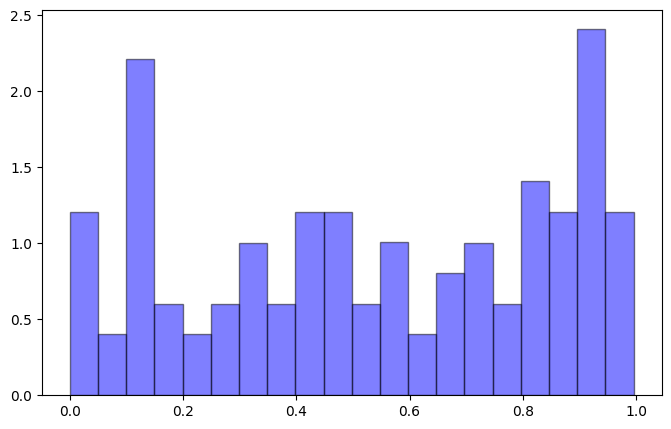

In [9]:
plt.figure(figsize=(8,5))
plt.hist(pvals,bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="distribution of pvalues")

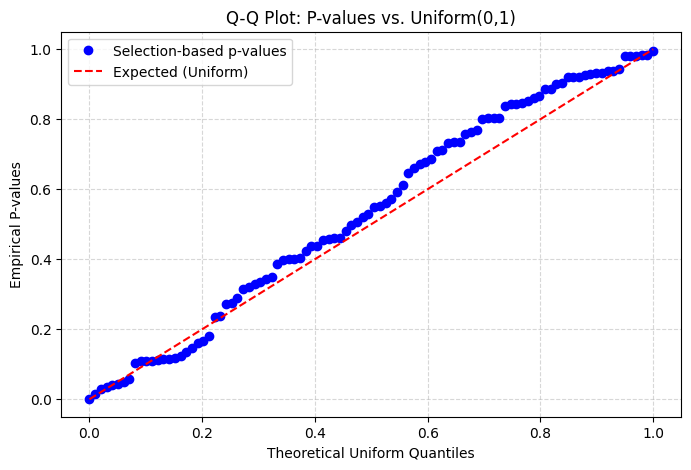

In [10]:
plt.figure(figsize=(8, 5))
sorted_p_values = np.sort(pvals)
theoretical_quantiles = np.linspace(0, 1, 100)

plt.plot(theoretical_quantiles, sorted_p_values, marker='o', linestyle='', color="blue",
         label="Selection-based p-values")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
plt.xlabel("Theoretical Uniform Quantiles")
plt.ylabel("Empirical P-values")
plt.title("Q-Q Plot: P-values vs. Uniform(0,1)")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

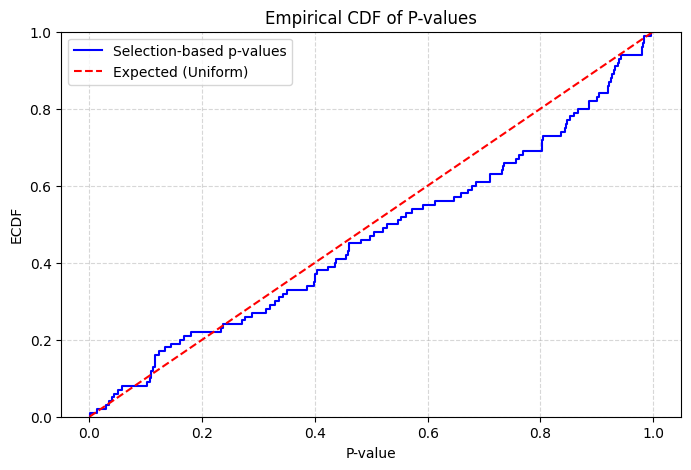

In [11]:
plt.figure(figsize=(8, 5))
sns.ecdfplot(pvals, color="blue", label="Selection-based p-values")
plt.plot([0, 1], [0, 1], linestyle="--", color="red", label="Expected (Uniform)")
plt.xlabel("P-value")
plt.ylabel("ECDF")
plt.title("Empirical CDF of P-values")
plt.legend()
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

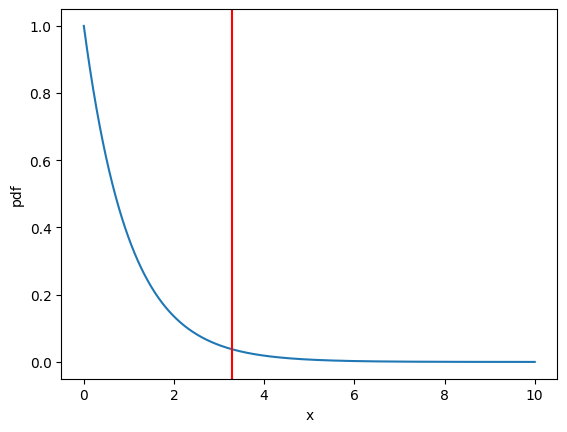

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import f

d1 = 2
d2 = 392

x = np.linspace(0.001, 10, 1000)
y = f.pdf(x, d1, d2)

plt.plot(x, y)
plt.axvline(x= 3.29,color = "red")
plt.xlabel("x")
plt.ylabel("pdf")
plt.show()


In [3]:
pvals

[0.3795457231757352,
 0.20454944053818677,
 0.905553713517347,
 0.33166241540424685,
 0.39945276716269223,
 0.305109329905759,
 0.7333245460430365,
 0.13823848884819503,
 0.9575325073612825,
 0.4451730480388141]

In [21]:
# generate an example dataset with 3 clusters
X, y = generate_data_barbers(20, 12,1, n_clusters=2)
labels = np.unique(y)

model = AgglomerativeClustering(X, tau=0.1,n_clusters=1,linkage="centroid",random_state=48)
model.fit(dendrogram=True) # To draw dendrogram, have to set dendrogram = True

In [22]:
winning_nodes = list(model.existing_clusters_log.keys())
key = winning_nodes[-1] #test for last merge for example
node = key[0].parent
p_value, obs_target = model.merge_inference_F(node,limit=100)
print("p-value computed",p_value)
print("observed statistics",obs_target)

p-value computed 4.714382009361399e-24
observed statistics 967.9248787055503


In [4]:
p_value, obs_target,_ = model.merge_inference_F_grid(node,ngrid=2000, ncoarse = 50, grid_width = 200)
print("p-value computed",p_value)
print("observed statistics",obs_target) 

p-value computed 0.30879332184738956
observed statistics 4.214360750296027


In [13]:
pvals_diff  = []
for _ in range(300):
    X= generate_null_data(50,2,np.zeros(2),1)
    model = AgglomerativeClustering(X, tau=0.1,n_clusters=3,linkage="single")
    model.fit()
    winning_nodes = list(model.existing_clusters_log.keys())
    key = winning_nodes[-1] #test for last merge for example
    node = key[0].parent
    pval1, _ = model.merge_inference_F(node,limit=100)
    pval2, _,_ = model.merge_inference_F_grid(node,ngrid=2000, ncoarse = 20, grid_width = 180)
    pvals_diff.append(np.abs(pval1-pval2))


KeyboardInterrupt: 

In [2]:
plt.figure(figsize=(8,5))
plt.hist(pvals_diff,bins=20, density=True, alpha=0.5, color="blue", edgecolor="black",
             label="abs difference between p-value from quad and from grid")

NameError: name 'pvals_diff' is not defined

<Figure size 800x500 with 0 Axes>

/Users/judydw/Documents/GitHub/SI_HierarchicalClustering/src/utils.py:135: RuntimeWarning: invalid value encountered in scalar divide
  observed_target = (m - 2) * np.linalg.norm(P0 @ X, 'fro') ** 2 / np.linalg.norm(P1 @ X, 'fro') ** 2


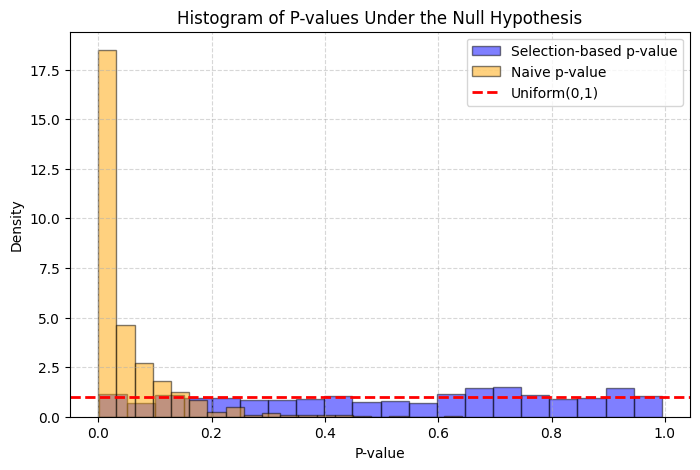

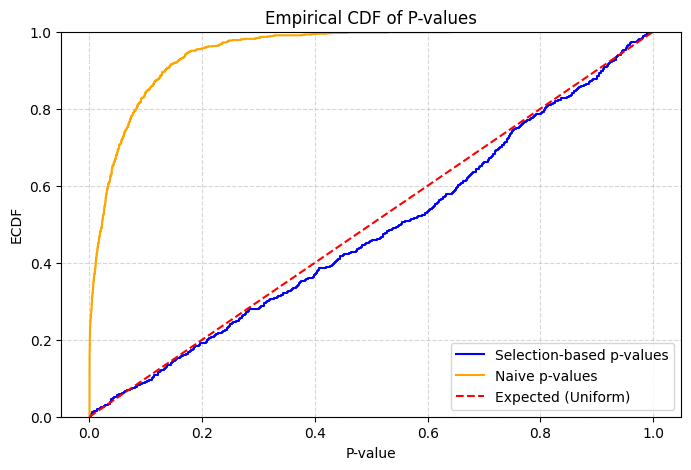

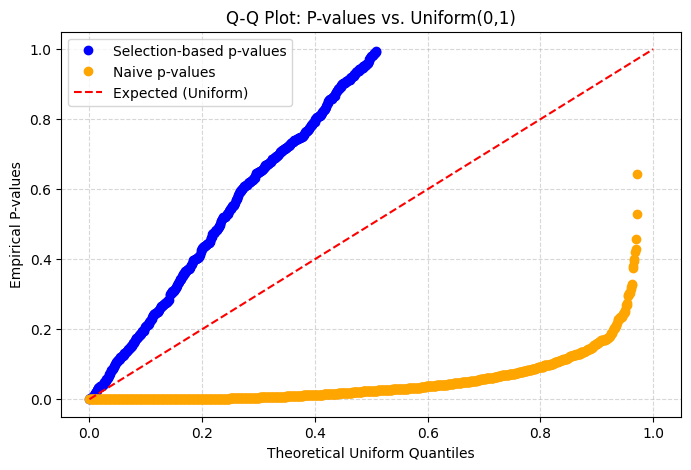

In [3]:
check_p_value_uniformity(30,2,1,3,0.1,-1,linkage="single", num_trials=1000)

In [3]:
import glob
files = glob.glob("../results/raw/fig9/pvals/*.csv")
df = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

In [11]:
df[df["pval_diff"]!=0]

,Unnamed: 0,pval,pval_g,pval_diff,alpha,reject
160,160,1.0,0.006301,0.993699,1.989423e-45,False
165,165,1.0,0.606650,0.393350,3.280004e-45,False
169,169,1.0,0.405056,0.594944,5.407813e-45,False
173,173,1.0,0.470164,0.529836,8.915977e-45,False
176,176,1.0,0.706203,0.293797,1.469996e-44,False
...,...,...,...,...,...,...
198995,194,1.0,NaN,NaN,2.657815e-41,False
198996,195,1.0,NaN,NaN,4.381996e-41,False
198997,196,1.0,NaN,NaN,7.224691e-41,False
198998,197,1.0,NaN,NaN,1.967347e-02,False


(array([43724.,   487.,   407.,   390.,   436.,   424.,   374.,   398.,
          391.,   928.]),
 array([0. , 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1. ]),
 <BarContainer object of 10 artists>)

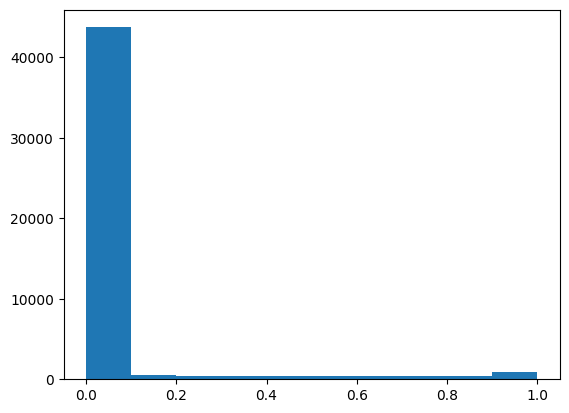

In [10]:
plt.hist(df["pval_diff"])